# RetailPulse AI – Day 3: Customer Segmentation using RFM Analysis

### Prepared By: Bansi Kanani

### Date: 31 May 2026

# Introduction

Customer segmentation helps businesses understand customer purchasing behavior and identify high-value customers.

RFM Analysis is a widely used customer segmentation technique based on:

- Recency
- Frequency
- Monetary Value

This notebook focuses on creating customer segments using RFM analysis.

# Objective

The objectives of Day 3 are:

- Calculate Recency
- Calculate Frequency
- Calculate Monetary Value
- Create RFM table
- Score customers
- Segment customers
- Identify high-value customers
- Generate business insights

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv(
    "cleaned_online_retail.csv"
)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1


# Dataset Shape

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 779425
Columns: 12


# Date Preparation

InvoiceDate must be converted into datetime format before calculating recency.

In [4]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  int64         
 1   StockCode    779425 non-null  object        
 2   Description  779425 non-null  object        
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[ns]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  float64       
 7   Country      779425 non-null  object        
 8   Revenue      779425 non-null  float64       
 9   Year         779425 non-null  int64         
 10  Month        779425 non-null  int64         
 11  Day          779425 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(5), object(3)
memory usage: 71.4+ MB


# Creating Reference Date

The reference date is used to calculate recency.

In [5]:
snapshot_date = (
    df["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

print(snapshot_date)

2011-12-10 12:50:00


# RFM Calculation

Recency = Days since last purchase

Frequency = Number of invoices

Monetary = Total revenue generated

In [6]:
rfm = df.groupby(
    "Customer ID"
).agg({
    "InvoiceDate": lambda x:
        (snapshot_date - x.max()).days,

    "Invoice": "nunique",

    "Revenue": "sum"
})

In [7]:
rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


# RFM Scoring

Customers are scored from 1 to 5 based on their Recency, Frequency, and Monetary values.

Higher scores indicate better customer engagement and value.

In [8]:
print(rfm.columns)

Index(['Recency', 'Frequency', 'Monetary'], dtype='object')


In [9]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

In [10]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    +
    rfm["F_Score"].astype(str)
    +
    rfm["M_Score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346.0,326,12,77556.46,2,5,5,255
12347.0,2,8,4921.53,5,4,5,545
12348.0,75,5,2019.40,3,4,4,344
12349.0,19,4,4428.69,5,3,5,535
12350.0,310,1,334.40,2,1,2,212


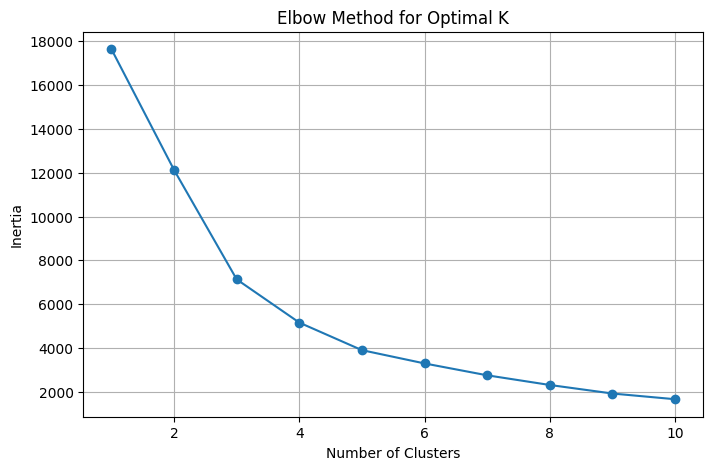

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Scale RFM features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Elbow Method
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.grid(True)
plt.show()

In [12]:
kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

rfm["KMeans_Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,KMeans_Cluster
Customer ID,,,,,,,,
12346.0,326,12,77556.46,2,5,5,255,1
12347.0,2,8,4921.53,5,4,5,545,4
12348.0,75,5,2019.40,3,4,4,344,4
12349.0,19,4,4428.69,5,3,5,535,4
12350.0,310,1,334.40,2,1,2,212,0


C:\Users\07mee\AppData\Local\Temp\ipykernel_11616\1834595014.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


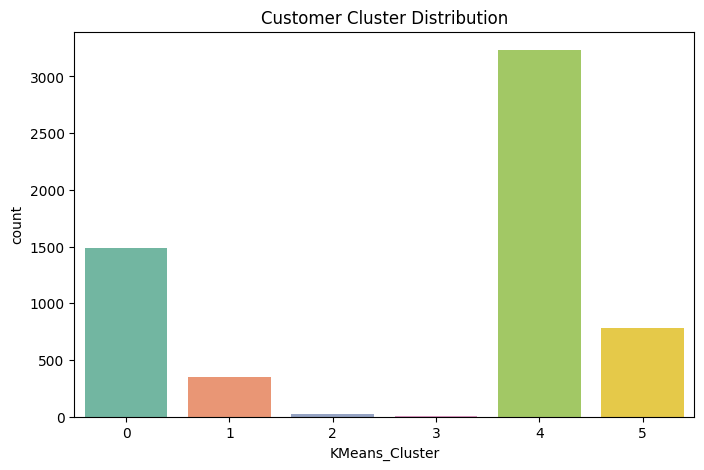

In [13]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    x="KMeans_Cluster",
    data=rfm,
    palette="Set2"
)

plt.title("Customer Cluster Distribution")

plt.show()

# Customer Segmentation

Customers are grouped into business-friendly segments based on their RFM scores.

In [14]:
def segment_customer(row):

    if row["R_Score"] == 5 and row["F_Score"] >= 4:
        return "VIP Customer"

    elif row["R_Score"] >= 4:
        return "Loyal Customer"

    elif row["R_Score"] >= 3:
        return "Potential Customer"

    else:
        return "At Risk Customer"

In [15]:
rfm["Segment"] = rfm.apply(
    segment_customer,
    axis=1
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,KMeans_Cluster,Segment
Customer ID,,,,,,,,,
12346.0,326,12,77556.46,2,5,5,255,1,At Risk Customer
12347.0,2,8,4921.53,5,4,5,545,4,VIP Customer
12348.0,75,5,2019.40,3,4,4,344,4,Potential Customer
12349.0,19,4,4428.69,5,3,5,535,4,Loyal Customer
12350.0,310,1,334.40,2,1,2,212,0,At Risk Customer


In [16]:
rfm["Segment"].value_counts()

Segment
At Risk Customer      2347
Loyal Customer        1527
Potential Customer    1167
VIP Customer           837
Name: count, dtype: int64

# Customer Segment Distribution

This visualization shows how customers are distributed across different business segments.

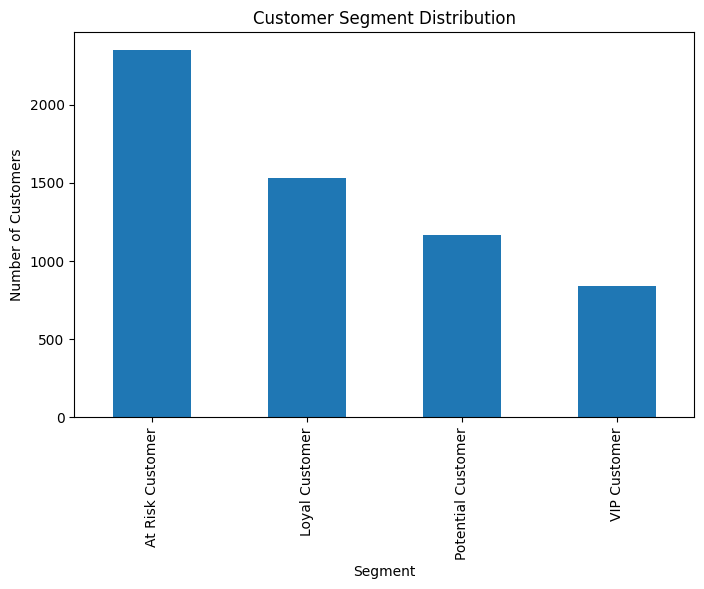

In [17]:
plt.figure(figsize=(8,5))

rfm["Segment"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Customer Segment Distribution"
)

plt.ylabel(
    "Number of Customers"
)

plt.show()

# High Value Customers

VIP customers represent the most valuable customer group and should be prioritized for retention strategies.

In [18]:
vip_customers = rfm[
    rfm["Segment"] == "VIP Customer"
]

vip_customers.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,KMeans_Cluster,Segment
Customer ID,,,,,,,,,
12347.0,2,8,4921.53,5,4,5,545,4,VIP Customer
12358.0,2,5,3887.07,5,4,5,545,4,VIP Customer
12362.0,3,11,5356.23,5,5,5,555,4,VIP Customer
12381.0,5,5,1845.31,5,4,4,544,4,VIP Customer
12388.0,16,8,3901.11,5,4,5,545,4,VIP Customer


# Segment Insights

Customer segmentation reveals different customer groups based on purchasing behavior.

VIP Customers:
- High value
- Frequent buyers
- Recently active

Loyal Customers:
- Regular purchasers
- Strong engagement

Potential Customers:
- Moderate activity
- Opportunity for growth

At Risk Customers:
- Inactive customers
- Require retention strategies

# Business Insights

1. A small group of customers contributes a significant portion of total revenue.

2. VIP customers should be prioritized through loyalty programs and personalized offers.

3. Loyal customers represent stable revenue sources.

4. At-risk customers may require targeted marketing campaigns to increase engagement.

5. RFM analysis provides a strong foundation for customer retention and churn prediction models.

# Challenges Faced

Creating meaningful customer segments required careful calculation of recency, frequency, and monetary metrics.

The large transaction volume required efficient aggregation and processing techniques.

# Saving RFM Dataset

The customer-level RFM dataset is saved for future customer analytics and churn prediction tasks.

In [19]:
rfm.to_csv(
    "customer_rfm.csv",
    index=True
)

print("RFM dataset saved successfully.")

RFM dataset saved successfully.


# Conclusion

RFM analysis was successfully performed on the Online Retail II dataset.

Customer segmentation helped identify VIP, Loyal, Potential, and At Risk customers based on purchasing behavior.

The resulting customer-level dataset will support future customer analytics, churn prediction, and marketing optimization initiatives.